In [ ]:
#!/bin/bash
!curl -L -o fer2013.zip https://www.kaggle.com/api/v1/datasets/download/msambare/fer2013

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 60.3M  100 60.3M    0     0  21.4M      0  0:00:02  0:00:02 --:--:-- 34.6M


In [ ]:
from zipfile import ZipFile

with ZipFile("fer2013.zip", "r") as f:
    f.extractall("./data")

In [ ]:
import os

for root, dirs, files in os.walk("./data"):
  print(root, len(files))
  if files:
    print(files[:5])

./data 0
./data/test 0
./data/test/fear 1024
['PrivateTest_29191497.jpg', 'PublicTest_977248.jpg', 'PrivateTest_45959215.jpg', 'PrivateTest_17558149.jpg', 'PublicTest_16937676.jpg']
./data/test/happy 1774
['PublicTest_8121981.jpg', 'PublicTest_18243231.jpg', 'PrivateTest_65255886.jpg', 'PrivateTest_33336951.jpg', 'PublicTest_51439.jpg']
./data/test/sad 1247
['PublicTest_86781056.jpg', 'PrivateTest_48581881.jpg', 'PrivateTest_80960922.jpg', 'PrivateTest_42592677.jpg', 'PrivateTest_76882408.jpg']
./data/test/surprise 831
['PrivateTest_6719287.jpg', 'PublicTest_24011006.jpg', 'PrivateTest_68250414.jpg', 'PrivateTest_38805770.jpg', 'PrivateTest_17526434.jpg']
./data/test/disgust 111
['PrivateTest_89077668.jpg', 'PublicTest_1274561.jpg', 'PrivateTest_51400934.jpg', 'PrivateTest_53414692.jpg', 'PublicTest_41393563.jpg']
./data/test/angry 958
['PublicTest_21110779.jpg', 'PublicTest_50685895.jpg', 'PrivateTest_97227751.jpg', 'PrivateTest_12008383.jpg', 'PublicTest_85354228.jpg']
./data/test/ne

In [ ]:
import torch

In [ ]:
sorted(os.listdir("./data/train"))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [ ]:
class CFG:
    DATA_ROOT   = "./data"
    TRAIN_DIR   = "./data/train"
    TEST_DIR    = "./data/test"

    BATCH_SIZE  = 32
    NUM_WORKERS = 2
    PIN_MEMORY  = True

    IMG_SIZE    = 224
    NUM_CLASSES = 7

    EPOCHS      = 10
    LR          = 1e-3
    WEIGHT_DECAY = 1e-4

    DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
    SEED        = 42

    CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [ ]:
from pathlib import Path

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def build_samples_from_folder(root_dir, class_names):
    samples = []
    root_dir = Path(root_dir)

    for label, class_name in enumerate(class_names):
        class_dir = root_dir / class_name

        if not class_dir.exists():
            print(f"Warning: class folder not found -> {class_dir}")
            continue

        for img_path in class_dir.rglob("*"):
            if img_path.suffix.lower() in IMG_EXTS:
                samples.append((str(img_path), label))

    return samples

In [ ]:
train_samples = build_samples_from_folder(CFG.TRAIN_DIR, CFG.CLASS_NAMES)
test_samples = build_samples_from_folder(CFG.TEST_DIR, CFG.CLASS_NAMES)

In [ ]:
print("train samples:", len(train_samples))
print("test samples :", len(test_samples))
print(train_samples[:5])

train samples: 28709
test samples : 7178
[('data/train/angry/Training_3284854.jpg', 0), ('data/train/angry/Training_63918104.jpg', 0), ('data/train/angry/Training_55896528.jpg', 0), ('data/train/angry/Training_84548986.jpg', 0), ('data/train/angry/Training_14690040.jpg', 0)]


In [ ]:
from torchvision import transforms

def get_transforms(split: str = "train"):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    base = [
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]

    if split == "train":
        return transforms.Compose([
            transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

    return transforms.Compose(base)

def get_inference_transform():
    return get_transforms(split="test")

In [ ]:
from pathlib import Path

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def build_samples_from_folder(root_dir, class_names):
    samples = []
    root_dir = Path(root_dir)

    for label, class_name in enumerate(class_names):
        class_dir = root_dir / class_name

        if not class_dir.exists():
            print(f"Warning: class folder not found -> {class_dir}")
            continue

        for img_path in class_dir.rglob("*"):
            if img_path.suffix.lower() in IMG_EXTS:
                samples.append((str(img_path), label))

    return samples

In [ ]:
train_samples = build_samples_from_folder(CFG.TRAIN_DIR, CFG.CLASS_NAMES)
test_samples  = build_samples_from_folder(CFG.TEST_DIR, CFG.CLASS_NAMES)

print("train samples:", len(train_samples))
print("test samples :", len(test_samples))
print(train_samples[:5])

train samples: 28709
test samples : 7178
[('data/train/angry/Training_3284854.jpg', 0), ('data/train/angry/Training_63918104.jpg', 0), ('data/train/angry/Training_55896528.jpg', 0), ('data/train/angry/Training_84548986.jpg', 0), ('data/train/angry/Training_14690040.jpg', 0)]


In [ ]:
train_ds = SafeImageDataset(
    samples=train_samples,
    transform=get_transforms("train"),
    min_size=32,
    force_rgb=True,
    verify_image=True,
    max_skip_attempts=20,
    log_warnings=False
)

test_ds = SafeImageDataset(
    samples=test_samples,
    transform=get_transforms("test"),
    min_size=32,
    force_rgb=True,
    verify_image=True,
    max_skip_attempts=20,
    log_warnings=False
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=CFG.PIN_MEMORY
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=CFG.PIN_MEMORY
)

In [ ]:
#access test

xb,yb = next(iter(train_loader))

print("xb shape:", xb.shape)
print("yb shape:", yb.shape)
print("xb dtype:", xb.dtype)
print("yb dtype:", yb.dtype)
print("label range:", yb.min().item(), yb.max().item())

xb shape: torch.Size([32, 3, 224, 224])
yb shape: torch.Size([32])
xb dtype: torch.float32
yb dtype: torch.int64
label range: 0 5


In [ ]:
for i, class_name in enumerate(CFG.CLASS_NAMES):
    train_count = sum(1 for _, y in train_samples if y == i)
    test_count  = sum(1 for _, y in test_samples if y == i)
    print(f"{i} | {class_name:10s} | train={train_count:5d} | test={test_count:5d}")

0 | angry      | train= 3995 | test=  958
1 | disgust    | train=  436 | test=  111
2 | fear       | train= 4097 | test= 1024
3 | happy      | train= 7215 | test= 1774
4 | neutral    | train= 4965 | test= 1233
5 | sad        | train= 4830 | test= 1247
6 | surprise   | train= 3171 | test=  831


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):

    def __init__(self, num_classes=7):
        super().__init__()

        # conv blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)

        # pooling
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, num_classes)

        # dropouts
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.3)

    def forward(self, x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))


        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)

        return x

In [ ]:
model = BaselineCNN(num_classes=CFG.NUM_CLASSES).to(CFG.DEVICE)
print(f"Model: {model}")

Model: BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=7, bias=True)
  (dropout1): Dropout(p=0.5, inplace=Fals

In [ ]:
#sanity check
x = torch.randn(2,3,224,224).to(CFG.DEVICE)
out = model(x)
print(out.shape)

torch.Size([2, 7])


In [ ]:
#class weights

import torch
import torch.nn as nn

train_counts = torch.tensor(
    [3995, 436, 4097, 7215, 4965, 4830, 3171],
    dtype=torch.float32
)

class_weights = train_counts.sum() / (len(train_counts) * train_counts)
class_weights = class_weights.to(CFG.DEVICE)

print(class_weights)

tensor([1.0266, 9.4066, 1.0010, 0.5684, 0.8260, 0.8491, 1.2934],
       device='cuda:0')


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:

        x,y = x.to(CFG.DEVICE), y.to(CFG.DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:

        x = x.to(CFG.DEVICE)
        y = y.to(CFG.DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
def show_sample_predictions(
    model: nn.Module,
    dataset,
    class_names: List[str],
    n: int = 16,
    cols: int = 4,
    save_path: Optional[str] = "sample_predictions.png",
):
    model.eval()

    inv_norm = transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    )

    n = min(n, len(dataset))
    indices = random.sample(range(len(dataset)), n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    fig.suptitle("Sample Predictions", fontsize=16, fontweight="bold")

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img_tensor, true_label = dataset[idx]

            x = img_tensor.unsqueeze(0).to(CFG.DEVICE)

            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            pred_label = torch.argmax(probs, dim=1).item()
            confidence = torch.max(probs, dim=1).values.item()

            img_display = inv_norm(img_tensor.cpu())
            img_display = img_display.permute(1, 2, 0).clamp(0, 1).numpy()

            correct = pred_label == true_label
            color = "green" if correct else "red"
            symbol = "v" if correct else "x"

            ax.imshow(img_display)
            ax.set_title(
                f"{symbol} Pred: {class_names[pred_label]}\n"
                f"True: {class_names[true_label]}\n"
                f"Conf: {confidence:.1%}",
                fontsize=9,
                color=color,
            )

            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

            ax.set_xticks([])
            ax.set_yticks([])

    for ax in axes[len(indices):]:
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved -> {save_path}")

    plt.show()

In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = -1.0

for epoch in range(1, CFG.EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = evaluate(
        model,
        test_loader,
        criterion
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_baseline_cnn.pth")

    print(
        f"Epoch {epoch:02d}/{CFG.EPOCHS} | "
        f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f} | "
        f"best val acc: {best_val_acc:.4f}"
    )

Epoch 01/10 | train loss: 2.0364 | train acc: 0.1471 | val loss: 1.9389 | val acc: 0.1332 | best val acc: 0.1332
Epoch 02/10 | train loss: 1.9475 | train acc: 0.1738 | val loss: 1.9279 | val acc: 0.2471 | best val acc: 0.2471
Epoch 03/10 | train loss: 1.9479 | train acc: 0.1999 | val loss: 1.9244 | val acc: 0.1737 | best val acc: 0.2471
Epoch 04/10 | train loss: 1.9439 | train acc: 0.1812 | val loss: 1.9203 | val acc: 0.2471 | best val acc: 0.2471
Epoch 05/10 | train loss: 1.9292 | train acc: 0.1972 | val loss: 1.8671 | val acc: 0.2243 | best val acc: 0.2471
Epoch 06/10 | train loss: 1.8531 | train acc: 0.2394 | val loss: 1.7923 | val acc: 0.3122 | best val acc: 0.3122
Epoch 07/10 | train loss: 1.7776 | train acc: 0.2807 | val loss: 1.6527 | val acc: 0.3653 | best val acc: 0.3653
Epoch 08/10 | train loss: 1.6814 | train acc: 0.3532 | val loss: 1.5183 | val acc: 0.4188 | best val acc: 0.4188
Epoch 09/10 | train loss: 1.5826 | train acc: 0.3955 | val loss: 1.4406 | val acc: 0.4512 | best

In [ ]:
model.load_state_dict(torch.load("best_baseline_cnn.pth", map_location=CFG.DEVICE))
model.to(CFG.DEVICE)

In [ ]:
print(history)

{'train_loss': [2.036422560089513, 1.9474826301666857, 1.9479196770960454, 1.9438502753373452, 1.9291818192969412, 1.8531476914967784, 1.777569760905525, 1.6813754734480915, 1.5825941757812176, 1.5171971165102858], 'train_acc': [0.1470618969661082, 0.17377825768922636, 0.199867637326274, 0.18123236615695426, 0.19715071928663486, 0.2393674457487199, 0.28071336514681805, 0.3531645128705284, 0.3954509038977324, 0.4217144449475774], 'val_loss': [1.9388599322014248, 1.9279333418476512, 1.9244069563508797, 1.9203063707625379, 1.8671496127368548, 1.7922577579960115, 1.6527194072025073, 1.5183472581712207, 1.4406099959182421, 1.4830009763903125], 'val_acc': [0.13318473112287546, 0.24714405126776262, 0.173725271663416, 0.24714405126776262, 0.22429646140986348, 0.31220395653385347, 0.36528280858177764, 0.41877960434661465, 0.4512398996935079, 0.44218445249373084]}


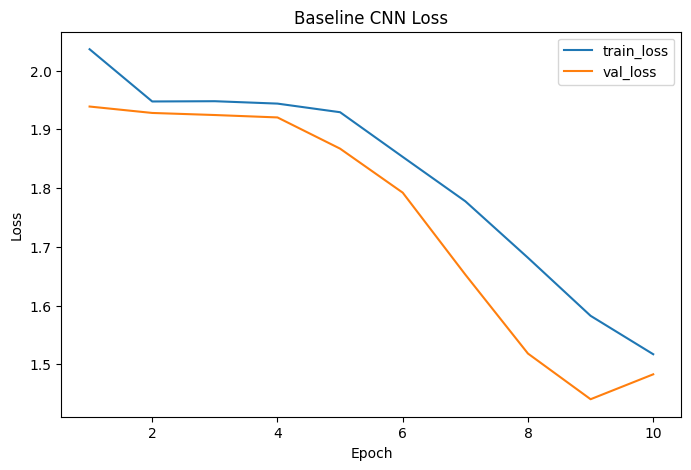

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()
plt.show()

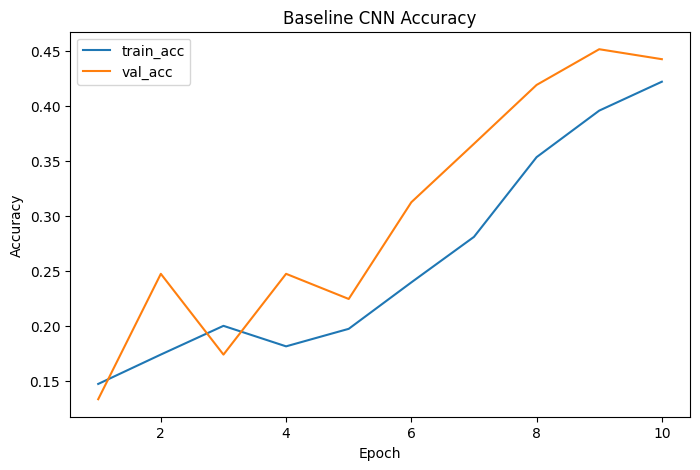

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()
plt.show()

In [ ]:
show_sample_predictions(
    model=model,
    dataset=test_ds,
    class_names=CFG.CLASS_NAMES,
    n=16,
    cols=4,
    save_path="baseline_sample_predictions.png"
)

# ResNet18

In [ ]:
from torchvision import transforms

def get_transforms(split: str = "train"):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if split == "train":
        return transforms.Compose([
            transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10,
                hue=0.02
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

    return transforms.Compose([
        transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

In [ ]:
#resnet 18 model

class ResNet18Emotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        if pretrained:
            weights = models.ResNet18_Weights.DEFAULT
        else:
            weights = None

        self.backbone = models.resnet18(weights=weights)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        return x

In [ ]:
resnet_model = ResNet18Emotion(
    num_classes=CFG.NUM_CLASSES,
    pretrained=True
).to(CFG.DEVICE)

print(resnet_model)

ResNet18Emotion(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [ ]:
x = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(CFG.DEVICE)
out = resnet_model(x)
print(out.shape)

torch.Size([2, 7])


In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

resnet_optimizer = torch.optim.Adam(
    resnet_model.parameters(),
    lr=1e-4,
    weight_decay=CFG.WEIGHT_DECAY
)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [ ]:
best_val_acc = -1.0

for epoch in range(1, CFG.EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        resnet_model,
        train_loader,
        criterion,
        resnet_optimizer
    )

    val_loss, val_acc = evaluate(
        resnet_model,
        test_loader,
        criterion
    )

    scheduler.step(val_acc)

    resnet_history["train_loss"].append(train_loss)
    resnet_history["train_acc"].append(train_acc)
    resnet_history["val_loss"].append(val_loss)
    resnet_history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet_model.state_dict(), "best_resnet18_emotion.pth")

    current_lr = resnet_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d}/{CFG.EPOCHS} | "
        f"lr: {current_lr:.6f} | "
        f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f} | "
        f"best val acc: {best_val_acc:.4f}"
    )

Epoch 01/10 | lr: 0.000100 | train loss: 1.6936 | train acc: 0.4871 | val loss: 1.6842 | val acc: 0.5801 | best val acc: 0.5801
Epoch 02/10 | lr: 0.000100 | train loss: 1.5018 | train acc: 0.6055 | val loss: 1.6173 | val acc: 0.6208 | best val acc: 0.6208
Epoch 03/10 | lr: 0.000100 | train loss: 1.4209 | train acc: 0.6519 | val loss: 1.5940 | val acc: 0.6402 | best val acc: 0.6402
Epoch 04/10 | lr: 0.000100 | train loss: 1.3541 | train acc: 0.6908 | val loss: 1.5831 | val acc: 0.6565 | best val acc: 0.6565
Epoch 05/10 | lr: 0.000100 | train loss: 1.2955 | train acc: 0.7216 | val loss: 1.5810 | val acc: 0.6613 | best val acc: 0.6613
Epoch 06/10 | lr: 0.000100 | train loss: 1.2484 | train acc: 0.7526 | val loss: 1.5698 | val acc: 0.6726 | best val acc: 0.6726
Epoch 07/10 | lr: 0.000100 | train loss: 1.1891 | train acc: 0.7867 | val loss: 1.5780 | val acc: 0.6700 | best val acc: 0.6726
Epoch 08/10 | lr: 0.000100 | train loss: 1.1328 | train acc: 0.8152 | val loss: 1.5982 | val acc: 0.6755

In [ ]:
resnet_model.load_state_dict(
    torch.load("best_resnet18_emotion.pth", map_location=CFG.DEVICE)
)
resnet_model.to(CFG.DEVICE)

ResNet18Emotion(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

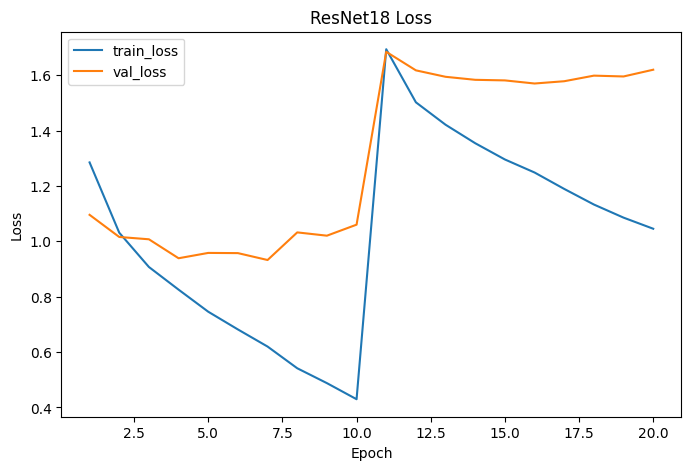

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(resnet_history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, resnet_history["train_loss"], label="train_loss")
plt.plot(epochs, resnet_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Loss")
plt.legend()
plt.show()

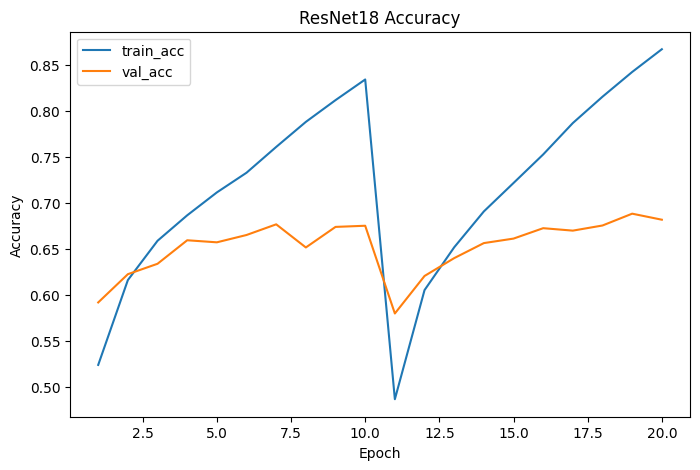

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, resnet_history["train_acc"], label="train_acc")
plt.plot(epochs, resnet_history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Accuracy")
plt.legend()
plt.show()

Saved -> resnet18_sample_predictions.png


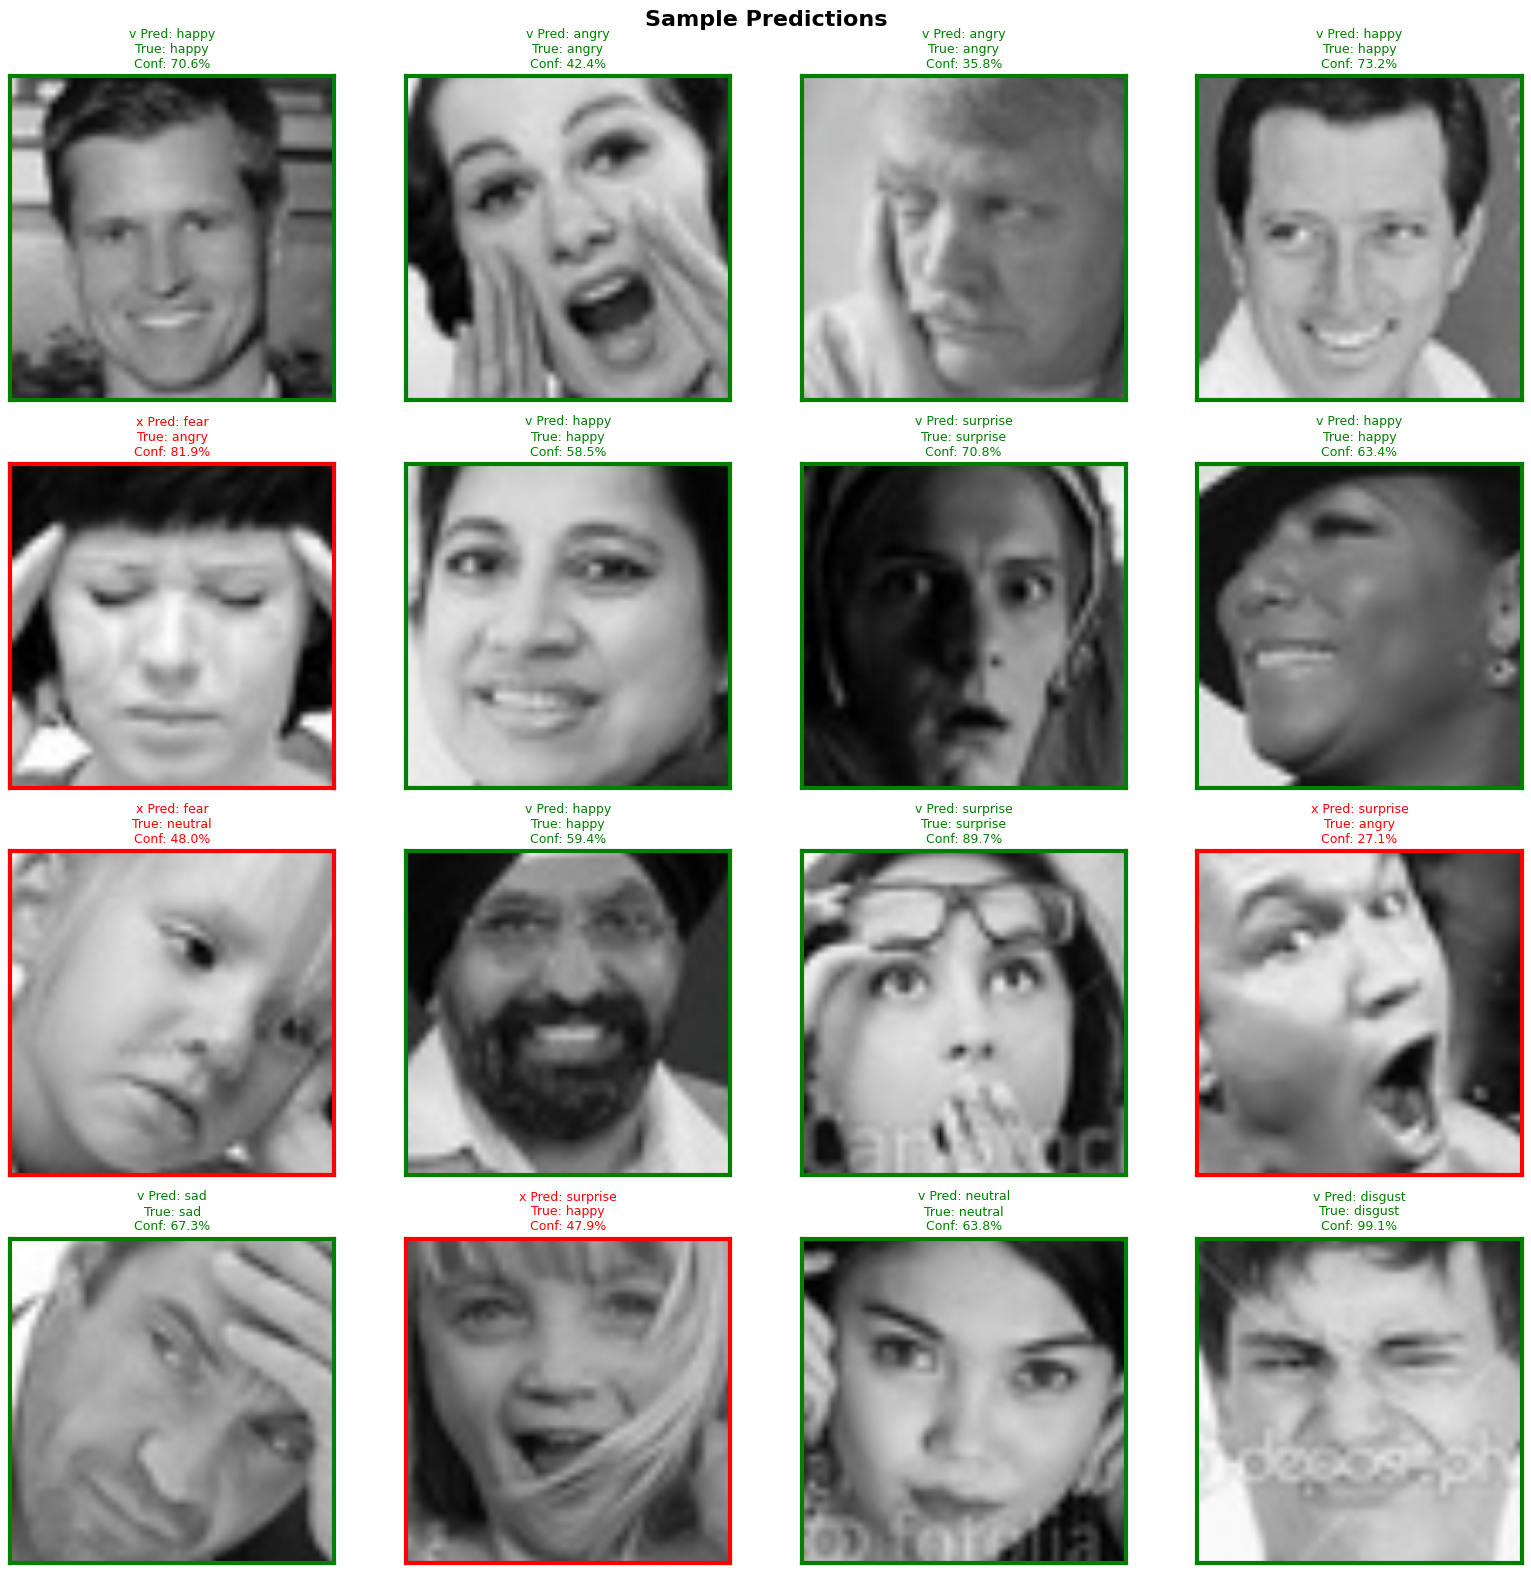

In [ ]:
show_sample_predictions(
    model=resnet_model,
    dataset=test_ds,
    class_names=CFG.CLASS_NAMES,
    n=16,
    cols=4,
    save_path="resnet18_sample_predictions.png"
)

#COMPARISON

In [ ]:
baseline_best_acc = max(history["val_acc"])
resnet_best_acc = max(resnet_history["val_acc"])

print("Baseline best val acc:", baseline_best_acc)
print("ResNet18 best val acc:", resnet_best_acc)

Baseline best val acc: 0.4512398996935079
ResNet18 best val acc: 0.6883533017553636


In [ ]:
import pandas as pd

baseline_best_acc = max(history["val_acc"])
resnet_best_acc = max(resnet_history["val_acc"])

comparison_df = pd.DataFrame({
    "Model": ["Baseline CNN", "ResNet18"],
    "Best Val Accuracy": [baseline_best_acc, resnet_best_acc]
})

comparison_df

,Model,Best Val Accuracy
0,Baseline CNN,0.451240
1,ResNet18,0.688353


#FINAL ACCURACY


In [ ]:
final_val_loss, final_val_acc = evaluate(
    resnet_model,
    test_loader,
    criterion
)

print(f"Final val loss: {final_val_loss:.4f}")
print(f"Final val acc : {final_val_acc:.4f}")

Final val loss: 1.5952
Final val acc : 0.6884


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()

    all_preds = []
    all_targets = []

    for x, y in loader:
        x = x.to(CFG.DEVICE)
        y = y.to(CFG.DEVICE)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

    return all_targets, all_preds

In [ ]:
y_true, y_pred = get_predictions(resnet_model, test_loader)

print("num targets:", len(y_true))
print("num preds  :", len(y_pred))

num targets: 7178
num preds  : 7178


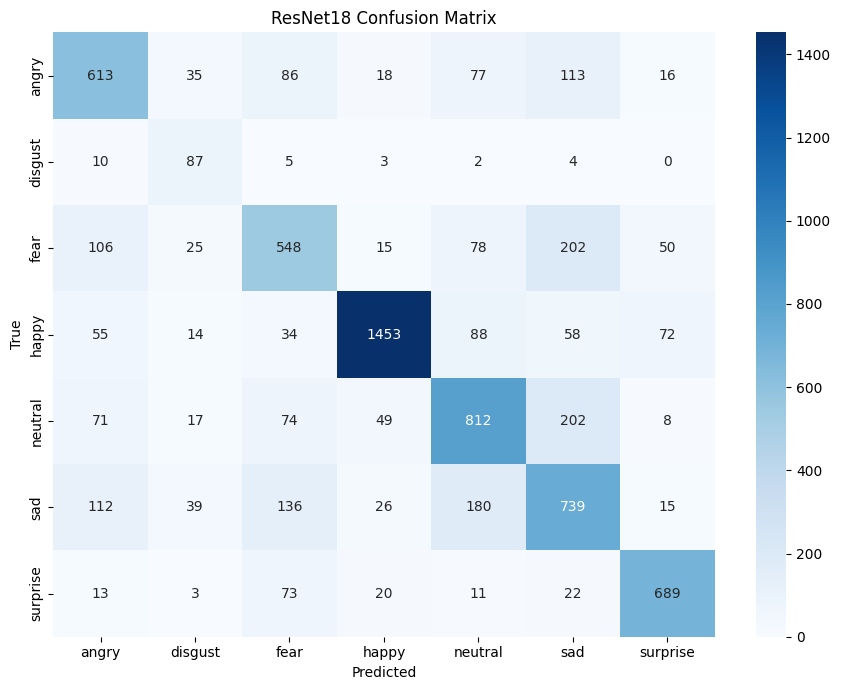

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CFG.CLASS_NAMES,
    yticklabels=CFG.CLASS_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet18 Confusion Matrix")
plt.tight_layout()
plt.show()

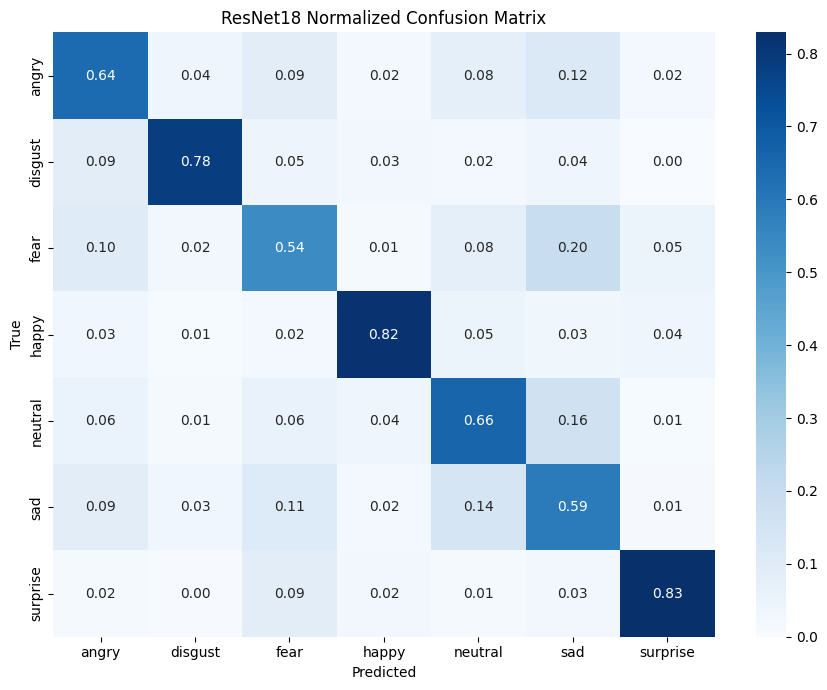

In [ ]:
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CFG.CLASS_NAMES,
    yticklabels=CFG.CLASS_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet18 Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=CFG.CLASS_NAMES,
    digits=4
))

              precision    recall  f1-score   support

       angry     0.6255    0.6399    0.6326       958
     disgust     0.3955    0.7838    0.5257       111
        fear     0.5732    0.5352    0.5535      1024
       happy     0.9173    0.8191    0.8654      1774
     neutral     0.6506    0.6586    0.6546      1233
         sad     0.5515    0.5926    0.5713      1247
    surprise     0.8106    0.8291    0.8198       831

    accuracy                         0.6884      7178
   macro avg     0.6463    0.6940    0.6604      7178
weighted avg     0.6995    0.6884    0.6920      7178



In [ ]:
torch.save(resnet_model.state_dict(), "best_model.pth")
print("Saved -> best_model.pth")

Saved -> best_model.pth


In [ ]:
import json

with open("class_names.json", "w") as f:
    json.dump(CFG.CLASS_NAMES, f)

print("Saved -> class_names.json")

Saved -> class_names.json


In [ ]:
from PIL import Image
import torch

def predict_image(image_path, model, class_names):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    x = get_inference_transform()(image).unsqueeze(0).to(CFG.DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)

    pred_idx = torch.argmax(probs, dim=1).item()
    pred_label = class_names[pred_idx]
    confidence = probs[0, pred_idx].item()

    prob_dict = {
        class_names[i]: float(probs[0, i].item())
        for i in range(len(class_names))
    }

    return {
        "pred_idx": pred_idx,
        "pred_label": pred_label,
        "confidence": confidence,
        "probs": prob_dict
    }

In [ ]:
sample_img = test_samples[0][0]

result = predict_image(
    image_path=sample_img,
    model=resnet_model,
    class_names=CFG.CLASS_NAMES
)

print("image:", sample_img)
print("pred label:", result["pred_label"])
print("confidence:", round(result["confidence"], 4))
print("probs:", result["probs"])

image: data/test/angry/PublicTest_21110779.jpg
pred label: surprise
confidence: 0.363
probs: {'angry': 0.025197695940732956, 'disgust': 0.29941633343696594, 'fear': 0.03460044786334038, 'happy': 0.02431323751807213, 'neutral': 0.15015198290348053, 'sad': 0.1033029779791832, 'surprise': 0.36301735043525696}


In [ ]:
import matplotlib.pyplot as plt

def show_single_prediction(image_path, model, class_names):
    result = predict_image(image_path, model, class_names)

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"Pred: {result['pred_label']} | Conf: {result['confidence']:.2%}",
        fontsize=12
    )
    plt.axis("off")
    plt.show()

    return result

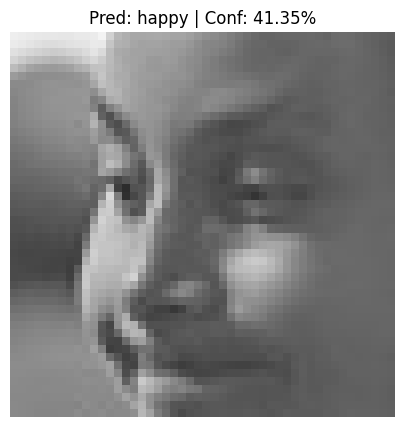

{'pred_idx': 3,
 'pred_label': 'happy',
 'confidence': 0.41348227858543396,
 'probs': {'angry': 0.010705286636948586,
  'disgust': 0.13557954132556915,
  'fear': 0.004747279919683933,
  'happy': 0.41348227858543396,
  'neutral': 0.2224849909543991,
  'sad': 0.1959715485572815,
  'surprise': 0.01702900230884552}}

In [ ]:
show_single_prediction(test_samples[10][0], resnet_model, CFG.CLASS_NAMES)

In [ ]:
def_shasod wdasdasjd asdi _as dask =
plt.axis("off")
plt.show()